In [156]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import xarray as xr
from amocatlas import read
from scipy.signal import detrend
from scipy.stats import linregress

import amoc_analysis.correlation_trends as ct


# Data

In [2]:
# Load the datasets
ts_gridded=xr.load_dataset(r"..\data\ts_gridded.nc")
moc_transports=xr.load_dataset(r"..\data\moc_transports.nc")
WH41N=read.wh41n()

Loading 1 Willis & Hobbs 41°N dataset(s):
  0. hobbs_willis_amoc41N_tseries.txt: Transport time series of Ekman volume, Northward geostrophc, Meridional Overturning volume and Meridional Overturning Heat



In [3]:
#Rename variables to be compatible with the script
rename_dict_ts = {
    'time':'TIME',
    'pressure': 'PRESSURE',
    'SG_east': 'PSAL_EAST',
    'SG_east_flag': 'PSAL_EAST_FLAG',
    'SG_mareast': 'PSAL_MAREAST',
    'SG_mareast_flag': 'PSAL_MAREAST_FLAG',
    'SG_marwest': 'PSAL_MARWEST',
    'SG_marwest_flag': 'PSAL_MARWEST_FLAG',
    'SG_wb3': 'PSAL_WB3',
    'SG_west': 'PSAL_WEST',
    'SG_west_flag': 'PSAL_WEST_FLAG',
    'TG_east': 'TEMP_EAST',
    'TG_east_flag': 'TEMP_EAST_FLAG',
    'TG_mareast': 'TEMP_MAREAST',
    'TG_mareast_flag': 'TEMP_MAREAST_FLAG',
    'TG_marwest': 'TEMP_MARWEST',
    'TG_marwest_flag': 'TEMP_MARWEST_FLAG',
    'TG_wb3': 'TEMP_WB3',
    'TG_west': 'TEMP_WEST',
    'TG_west_flag': 'TEMP_WEST_FLAG',
}

rename_dict_moc = {
    'time':'TIME',
    'moc_mar_hc10': 'MOC',
    't_therm10': 'TRANS_0_800',
    't_ud10': 'TRANS_1100_3000',
    't_ld10': 'TRANS_3000_5000',
    't_aiw10': 'TRANS_800_1100',
    't_ek10': 'TRANS_EKMAN',
    't_gs10': 'TRANS_FC',
    't_umo10': 'TRANS_UMO',
    't_bw10': 'TRANS_below_5000',
}

while True:
    try:
        ts_gridded = ts_gridded.rename(rename_dict_ts)
        print("Rename complete")
        break
    except Exception as e:
        print(f"Rename failed: {e}\nCheck if ts_gridded already has the right variable names.")
        break

while True:
    try:
        moc_transports = moc_transports.rename(rename_dict_moc)
        print("Rename complete")
        break
    except Exception as e:
        print(f"Rename failed: {e}\nCheck if moc_transports already has the right variable names.")
        break

Rename complete
Rename complete


# Part 1 (Geostrophic Transport)

In [4]:
# Calculate interior geostrophic transport
geo_transport=ct.geostrophy.interior_geostrophic_transport(ts_gridded)

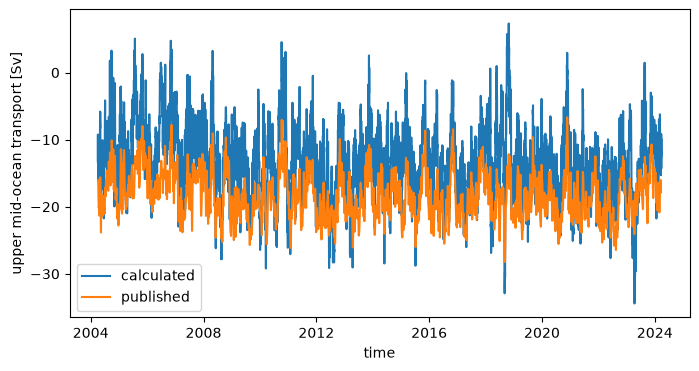

,Transport,Mean (Sv),Std (Sv)
0,calculated,-13.455613768215049,5.501136797675679
1,published,-18.36851235896635,3.4169937749592694


In [ ]:
plt.figure(figsize=(8,4))
plt.plot(geo_transport.TIME,geo_transport, label="calculated")
plt.plot(moc_transports["TRANS_UMO"].TIME,moc_transports["TRANS_UMO"],label="published")
plt.xlabel("time")
plt.ylabel("upper mid-ocean transport [Sv]")
plt.legend()
plt.savefig(r"../figures/assignment2/pub_vs_calc_umo_timeseries.png")
plt.show()

mean_geo=geo_transport.mean().values
mean_moc=moc_transports["TRANS_UMO"].mean().values
std_geo=geo_transport.std().values
std_moc=moc_transports["TRANS_UMO"].std().values

stats_dict=[{
        "Transport": "calculated",
        "Mean (Sv)":mean_geo,
        "Std (Sv)":std_geo,

    },
    {
            "Transport": "published",
            "Mean (Sv)":mean_moc,
            "Std (Sv)":std_moc,

    }]

pd.DataFrame(stats_dict)

### Correlation

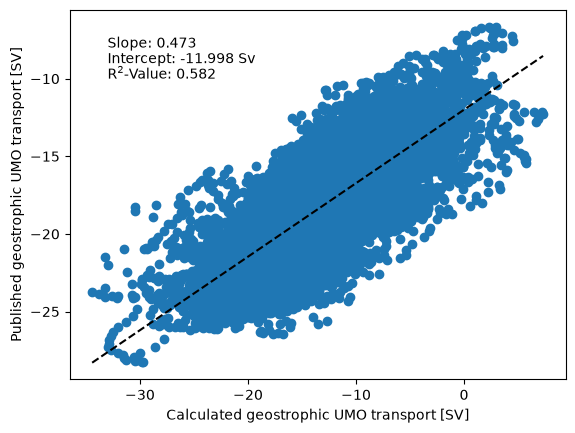

Slope:  0.47340746479552753
Intercept:  -11.997742798480221
R^2-Value:  0.581525358333152


In [61]:
x = np.asarray(geo_transport)
y = np.asarray(moc_transports["TRANS_UMO"])

mask = ~np.isnan(x) & ~np.isnan(y)
x_clean = x[mask]
y_clean = y[mask]

reg = linregress(x_clean, y_clean)

x_sort = np.sort(x_clean)
plt.scatter(x_clean, y_clean)
plt.plot(x_sort, reg.slope * x_sort + reg.intercept, c="black", ls="--")
plt.xlabel("Calculated geostrophic UMO transport [SV]")
plt.ylabel("Published geostrophic UMO transport [SV]")
plt.text(-33,-8,f"Slope: {reg.slope:.3f}")
plt.text(-33,-9,f"Intercept: {reg.intercept:.3f} Sv")
plt.text(-33,-10,f"R$^2$-Value: {reg.rvalue**2:.3f}")
plt.savefig(r"../figures/assignment2/correlation.png")
plt.show()

print("Slope: ",reg.slope)
print("Intercept: ",reg.intercept)
print("R^2-Value: ",reg.rvalue**2)

# Part 2 (Time Series)

## Remove the seasonal cycle

In [65]:
umo = moc_transports.TRANS_UMO
moc = moc_transports.MOC

mask = (~np.isnan(moc)) & (~np.isnan(umo))
moc_masked = moc.where(mask, drop=True)
umo_masked = umo.where(mask, drop=True)


# 3-month filter, rolling still on the DataArray, keeps TIME coord + attrs
moc_filtered = moc_masked.rolling(TIME=3*61, center=True).mean()
umo_filtered = umo_masked.rolling(TIME=3*61, center=True).mean()

# calc climatology
moc_clim = ct.seasonal.seasonal_climatology(moc_filtered)
umo_clim = ct.seasonal.seasonal_climatology(umo_filtered)

# deseason — now still has a proper TIME dim for remove_seasonal_cycle to use
moc_deseasoned = ct.seasonal.remove_seasonal_cycle(moc_filtered)
umo_deseasoned = ct.seasonal.remove_seasonal_cycle(umo_filtered)


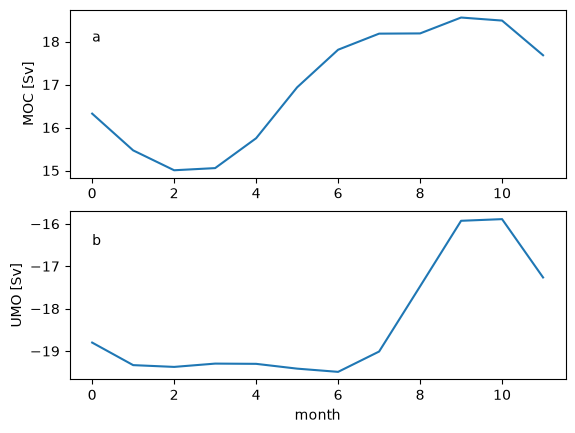

In [82]:
fig,ax=plt.subplots(2,1)
ax[0].plot(moc_clim)
ax[0].set_ylabel("MOC [Sv]")
ax[0].text(0,18,"a")
ax[1].plot(umo_clim)
ax[1].set_ylabel("UMO [Sv]")
ax[1].set_xlabel("month")
ax[1].text(0,-16.5,"b")

plt.savefig(r"../figures/assignment2/seasonal_cycles.png")

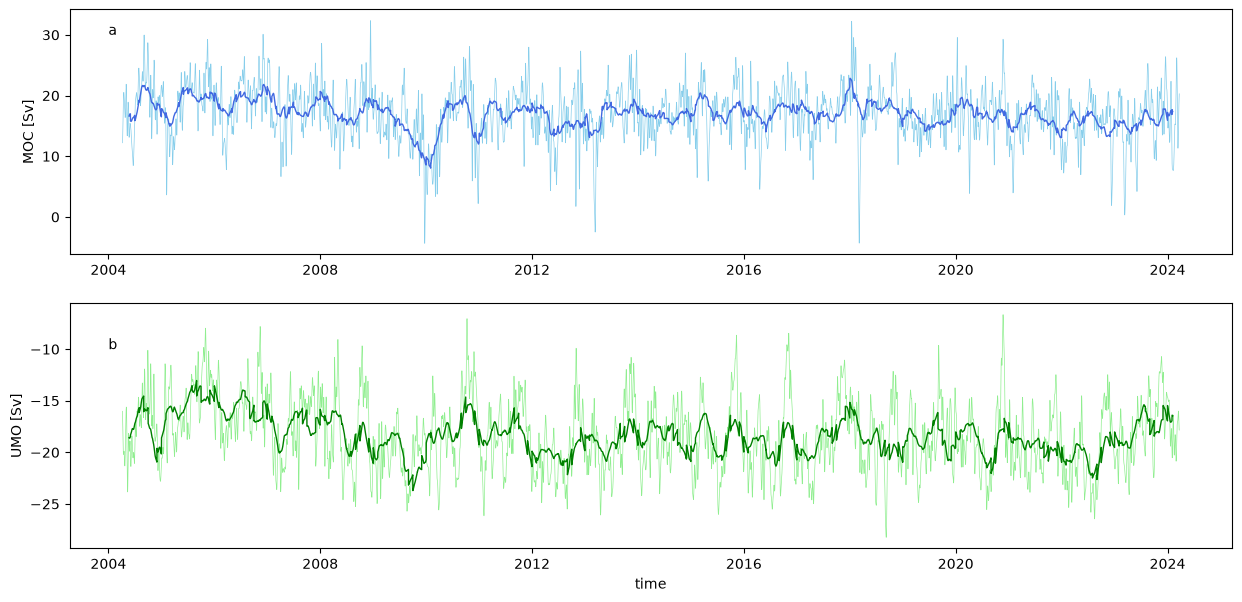

In [90]:
fig,ax=plt.subplots(2,1,figsize=(15,7))
ax[0].plot(moc.TIME,moc,lw=0.5,c="skyblue")
ax[0].plot(moc_deseasoned.TIME,moc_deseasoned,lw=1,c="royalblue")
ax[0].set_ylabel("MOC [Sv]")
ax[0].text(pd.Timestamp("2004"),30,"a")
ax[1].plot(umo.TIME,umo,lw=0.5,c="lightgreen")
ax[1].plot(umo_deseasoned.TIME,umo_deseasoned,lw=1,c="green")
ax[1].set_ylabel("UMO [Sv]")
ax[1].text(pd.Timestamp("2004"),-10,"b")
ax[1].set_xlabel("time")
plt.savefig(r"../figures/assignment2/deseasoned_timeseries.png")

## Autocorrelation

In [98]:
### Detrend first
moc_detrend = moc_masked.copy(data=detrend(moc_masked.values))
umo_detrend = umo_masked.copy(data=detrend(umo_masked.values))


corr_moc=ct.correlation.autocorr(moc_detrend)
corr_umo=ct.correlation.autocorr(umo_detrend)



tau_moc=ct.correlation.integral_timescale(moc_detrend,2)
tau_umo=ct.correlation.integral_timescale(umo_detrend,2)

37.0238457284896
45.03206386324544


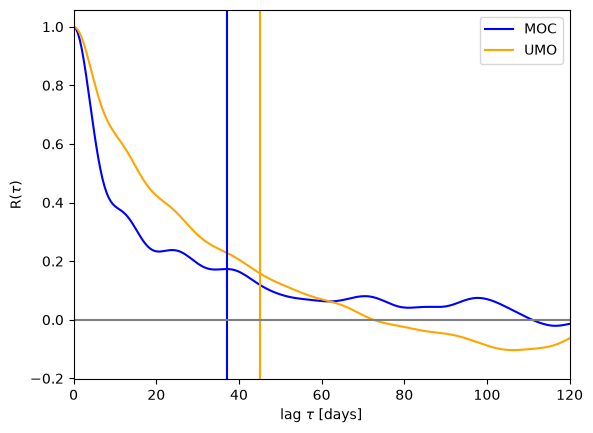

In [147]:
dt_days = 0.5  # 12h sampling → 0.5 days per lag

lags_days_moc = np.arange(len(corr_moc)) * dt_days
lags_days_umo = np.arange(len(corr_umo)) * dt_days

plt.plot(lags_days_moc, corr_moc, c="b", label="MOC")
plt.plot(lags_days_umo, corr_umo, c="orange", label="UMO")
plt.xlim(0,120)
plt.axvline(tau_moc/2, c="b")
plt.axvline(tau_umo/2, c="orange")
plt.axhline(0,c="grey")
plt.legend()
plt.ylabel(r"R($\tau$)")
plt.xlabel(r"lag $\tau$ [days]")
#plt.xscale("log")
plt.savefig(r"../figures/assignment2/autocorrelation.png")
print(tau_moc/2)
print(tau_umo/2)

## Trends

In [134]:
def time_to_years(time_da):
    """Convert an xarray datetime64 TIME coordinate to float years since start."""
    t = time_da.values.astype("datetime64[ns]")
    t0 = t[0]
    days = (t - t0) / np.timedelta64(1, "D")
    return days / 365.25  # float years since start

t_moc = time_to_years(moc_masked.TIME)
t_umo = time_to_years(umo_masked.TIME)

trend_moc=ct.trends.trend_with_significance(t_moc,moc_masked,2)
trend_umo=ct.trends.trend_with_significance(t_umo,umo_masked,2)

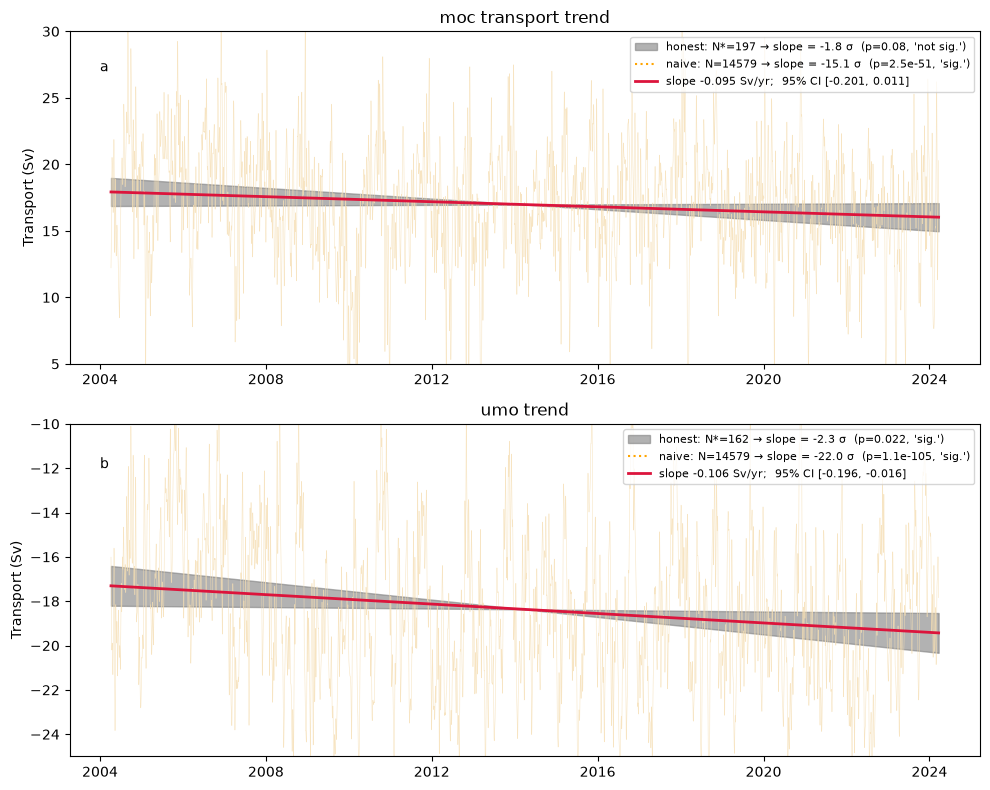

In [150]:
from amoc_analysis import plotting

fig, ax = plt.subplots(2, 1, figsize=(10,8))

plotting.plot_trend_with_sigma(ax[0], t_moc, moc_masked.TIME, moc_masked, moc_masked,
                       trend_moc, N_raw=len(moc_masked), title="moc transport trend")

plotting.plot_trend_with_sigma(ax[1], t_umo, umo_masked.TIME, umo_masked, umo_masked,
                       trend_umo, N_raw=len(umo_masked), title="umo trend")

plt.tight_layout()
ax[0].set_ylim(5,30)
ax[0].text(pd.Timestamp("2004"),27,"a")
ax[1].set_ylim(-25,-10)
ax[1].text(pd.Timestamp("2004"),-12,"b")
plt.savefig(r"../figures/assignment2/trends.png")
plt.show()

## Cross correlation

In [13]:
# Pick two series:
# WH41N   sampling:monthly     filter: 3-month low-pass (boxcar)
# RAPID   sampling:12h         filter: 10-day low-pass

rapid=moc_transports.MOC
wh41n=WH41N.MOC

#Filter the RAPID data
s = pd.Series(rapid.values, index=pd.to_datetime(moc_transports.TIME.values), dtype="float64")
rapid_3m= s.rolling("90D", center=True, min_periods=1).mean()

#Put Rapid on the same grid as WH41N
rapid_monthly = rapid_3m.resample("1MS").mean()

wh41n_series = pd.Series(wh41n.values, index=pd.to_datetime(WH41N.TIME.values), dtype="float64")

rapid_monthly.index = rapid_monthly.index.to_period("M").to_timestamp()
wh41n_series.index = wh41n_series.index.to_period("M").to_timestamp()


combined = pd.concat({"wh41n": wh41n_series, "rapid": rapid_monthly}, axis=1, join="inner")

wh41n_aligned = combined["wh41n"].to_xarray()
rapid_aligned = combined["rapid"].to_xarray()



In [14]:
#Remove seasonal cycle
wh41n_deseasoned=ct.seasonal.remove_seasonal_cycle(wh41n_aligned,group="index.month")
rapid_deseasoned=ct.seasonal.remove_seasonal_cycle(rapid_aligned,group="index.month")

#Calculkate cross correlation
lags_raw,r_raw=ct.correlation.cross_correlation(wh41n_aligned,rapid_aligned)
lags,r=ct.correlation.cross_correlation(wh41n_deseasoned,rapid_deseasoned)


Peak lag: -2 months


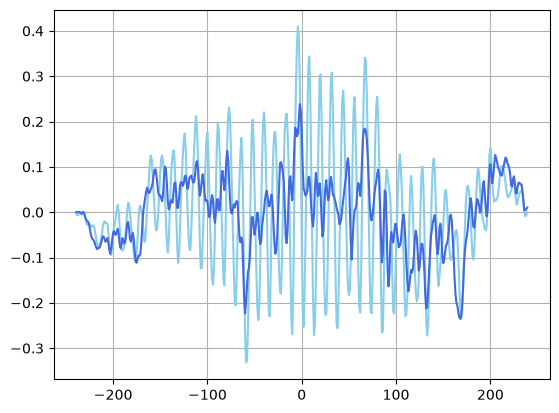

In [160]:
plt.plot(lags_raw,r_raw,c="skyblue")
plt.plot(lags,r,c="royalblue")
plt.grid()
plt.savefig(r"../figures/assignment2/crosscorrelation.png")

peak_lag = lags[np.argmax(r)]
print(f"Peak lag: {peak_lag} months")


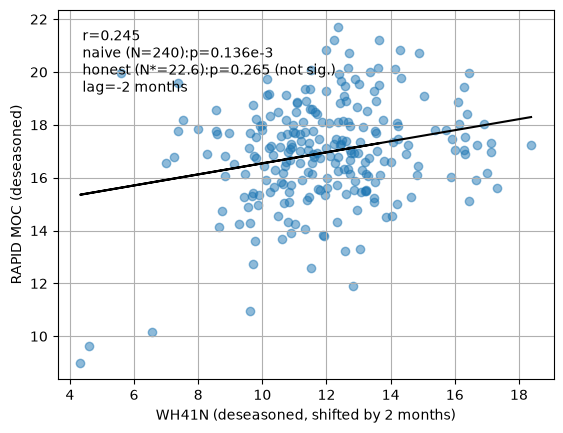

In [182]:
# shift WH41N by peak_lag months to align it with RAPID at the peak correlation
wh41n_shifted = wh41n_deseasoned.to_series().shift(-int(peak_lag))

df_peak = pd.concat({"wh41n": wh41n_shifted, "rapid": rapid_deseasoned.to_series()}, axis=1).dropna()

slope, intercept, r_value, p_lin, se = linregress(df_peak["wh41n"], df_peak["rapid"])

r_peak = r[np.argmax(r)]

Tstar_wh41n = ct.correlation.integral_timescale(wh41n_deseasoned,1)
Tstar_rapid = ct.correlation.integral_timescale(rapid_deseasoned,1)

# honest significance using effective N (from persistence of both series)
N = len(combined)
N_eff = N / (Tstar_wh41n + Tstar_rapid)
t_stat = r_value * np.sqrt((N_eff - 2) / (1 - r_value**2))
p_honest = 2 * stats.t.sf(np.abs(t_stat), df=N_eff - 2)
verdict = "sig." if p_honest < 0.05 else "not sig."

plt.figure()
plt.scatter(df_peak["wh41n"], df_peak["rapid"], alpha=0.5)
plt.plot(df_peak["wh41n"], slope*df_peak["wh41n"] + intercept,c="k")
plt.xlabel("WH41N (deseasoned, shifted by 2 months)")
plt.ylabel("RAPID MOC (deseasoned)")
plt.text(0.05, 0.95,
          f"r={r_value:.3f}\nnaive (N=240):p={p_lin*1000:.3f}e-3\n"
          f"honest (N*=22.6):p={p_honest:.3f} ({verdict})\nlag={peak_lag} months",
          transform=plt.gca().transAxes, va="top")
plt.grid()
plt.savefig(r"../figures/assignment2/crosscorrelation_scatter.png")

# Part 3 (Sensitivity of geostrohic transport against integration depth)

In [53]:
# Sensitivity of integration depth in geostrophic transport
geo_700=ct.geostrophy.interior_geostrophic_transport(ts_gridded,z_max=700)
geo_1000=ct.geostrophy.interior_geostrophic_transport(ts_gridded,z_max=1000)
geo_1100=ct.geostrophy.interior_geostrophic_transport(ts_gridded,z_max=1100)
geo_1300=ct.geostrophy.interior_geostrophic_transport(ts_gridded,z_max=1300)


In [59]:
results = []
for name, series in [("700 m", geo_700), ("1000 m", geo_1000), ("1100 m", geo_1100), ("1300 m", geo_1300)]:
    corr_with_1100 = np.corrcoef(series.values, geo_1100.values)[0, 1] #if name != "1100 m" else 1.0
    results.append({
        "Integration depth": name,
        "Mean (Sv)": series.mean().item(),
        "Std (Sv)": series.std().item(),
        "Correlation with 1100m": corr_with_1100,
    })

pd.DataFrame(results)

,Integration depth,Mean (Sv),Std (Sv),Correlation with 1100m
0,700 m,-16.375105,4.401429,0.984810
1,1000 m,-14.107682,5.290731,0.999062
2,1100 m,-13.455614,5.501137,1.000000
3,1300 m,-12.775780,5.874200,0.996607


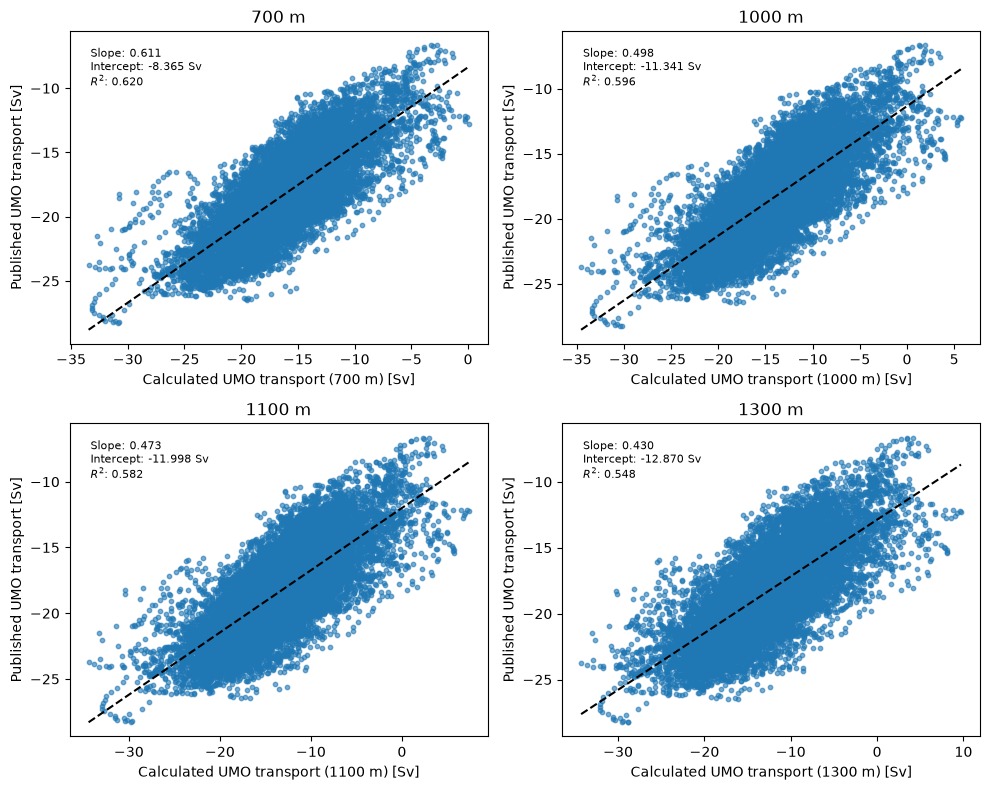

In [62]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.flatten()

for a, (name, series) in zip(ax, [("700 m", geo_700), ("1000 m", geo_1000),
                                    ("1100 m", geo_1100), ("1300 m", geo_1300)]):
    x = np.asarray(series)
    y = np.asarray(umo)

    mask = ~np.isnan(x) & ~np.isnan(y)
    x_clean = x[mask]
    y_clean = y[mask]

    reg = linregress(x_clean, y_clean)

    x_sort = np.sort(x_clean)
    a.scatter(x_clean, y_clean, s=10, alpha=0.6)
    a.plot(x_sort, reg.slope * x_sort + reg.intercept, c="black", ls="--")
    a.set_xlabel(f"Calculated UMO transport ({name}) [Sv]")
    a.set_ylabel("Published UMO transport [Sv]")
    a.set_title(name)

    # place text relative to axis limits instead of hardcoded data coords
    a.text(0.05, 0.95, f"Slope: {reg.slope:.3f}\nIntercept: {reg.intercept:.3f} Sv\n$R^2$: {reg.rvalue**2:.3f}",
           transform=a.transAxes, va="top", fontsize=8)

plt.tight_layout()
plt.savefig(r"../figures/assignment2/correlation_depths.png")
plt.show()
